In [6]:
import scanpy as sc
import anndata
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd
import scvelo as scv

# ENR

In [8]:
# dynamic
file_path = '/Users/choi_lab_sk/Library/CloudStorage/OneDrive-Personal/Choi_Lab_SK/project1_intestinal_crypt_bulk_scRNA-seq/sc_ver7/Trajectory_analysis/scVelo/1_ENR/20250320_dynamic_ENR_merge_data.h5ad'
dynamic_ENR = sc.read(file_path)

print(dynamic_ENR)

AnnData object with n_obs × n_vars = 3819 × 21416
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nUMI', 'nGene', 'Sample_Tag', 'Sample_Name', 'cells', 'log10GenesPerUMI', 'mitoRatio', 'batch', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'RNA_snn_res.0.05', 'RNA_snn_res.0.1', 'RNA_snn_res.0.15', 'RNA_snn_res.0.2', 'RNA_snn_res.0.25', 'RNA_snn_res.0.3', 'RNA_snn_res.0.35', 'RNA_snn_res.0.4', 'seurat_clusters', 'mitoFr', 'RNA_snn_res.0.8', 'pANN_0.25_0.02_38', 'doublet_check', 'scDblFinder.class', 'scDblFinder.score', 'pANN_0.25_0.05_28', 'pANN_0.25_0.01_9', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.01', 'RNA_snn_res.0.02', 'RNA_snn_res.0.03', 'RNA_snn_res.0.04', 'RNA_snn_res.0.06', 'RNA_snn_res.0.07', 'RNA_snn_res.0.08', 'RNA_snn_res.0.09', 'RNA_snn_res.0.11', 'RNA_snn_res.0.12', 'RNA_snn_res.0.13', 'RNA_snn_res.0.14', 'RNA_snn_res.0.16', 'RNA_snn_res.0.17', 'RNA_snn_res.0.18', 'RNA_snn_res.0.19', 'RNA_snn_res.0.21', 'RNA_snn_res.0.22

In [12]:
dynamic_ENR.uns['paga']

{'connectivities': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 222 stored elements in Compressed Sparse Row format>,
 'connectivities_tree': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 16 stored elements in Compressed Sparse Row format>,
 'groups': 'idents_clusters',
 'pos': array([[-3.20000121, -0.60696634],
        [ 1.71440533, -2.22193654],
        [-3.78511021, -4.15293165],
        [ 4.64043453,  0.3593233 ],
        [-5.81178567, -4.79365643],
        [11.30880025, -4.0516723 ],
        [-1.23629138,  0.78630726],
        [-1.50260675, -7.25895341],
        [-2.77899286, -7.00122507],
        [-1.7553623 , -5.71190663],
        [ 4.7140806 , -1.83811023],
        [-2.9758105 ,  3.67199127],
        [-0.13208878, -0.04452332],
        [-4.58085248,  3.02512829],
        [ 4.103838  ,  3.00847952],
        [-2.11046878,  1.03491084],
        [ 1.78352562,  7.38543741]]),
 'threshold': 0.02122490744212549,
 'transitions_confidence': <17x17 sparse

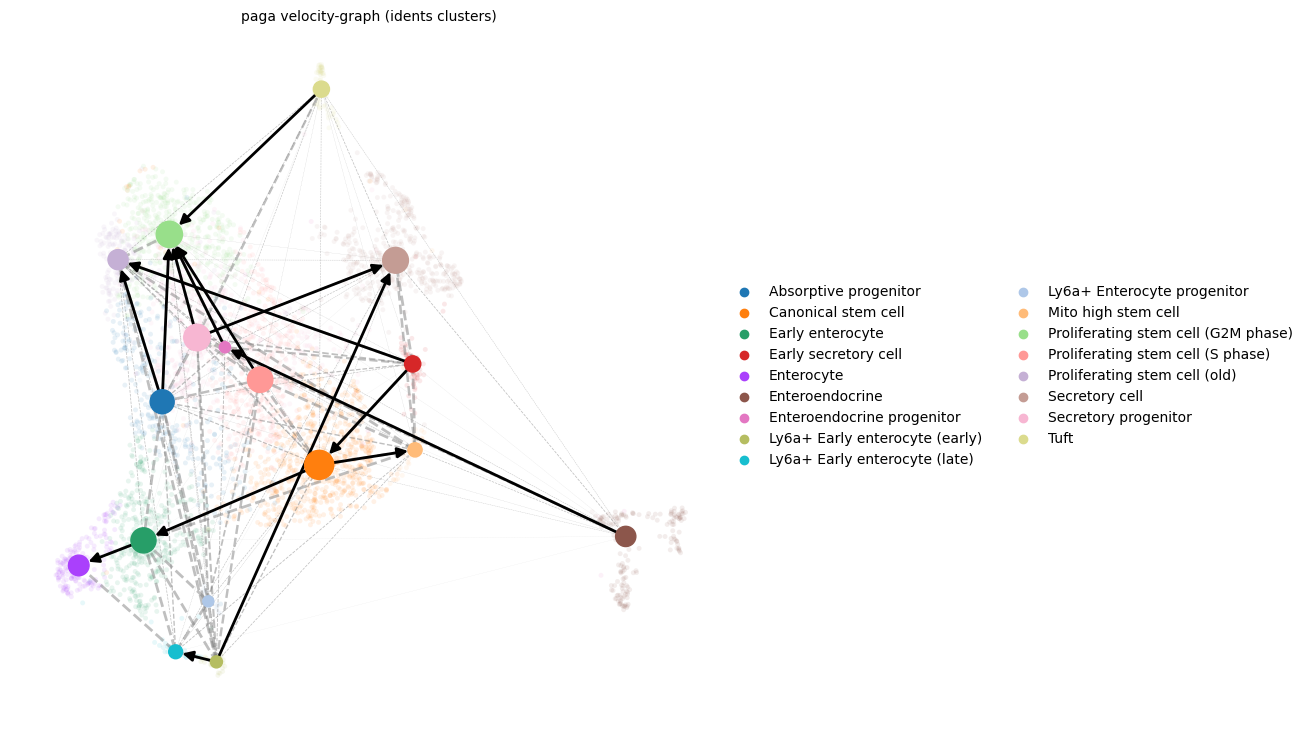

In [9]:
scv.pl.paga(dynamic_ENR, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5, figsize=(9,9))

In [15]:
clusters = dynamic_ENR.obs['idents_clusters'].astype('category').cat.categories
mat = dynamic_ENR.uns['paga']['transitions_confidence'].toarray()
df = pd.DataFrame(mat, index=clusters, columns=clusters)
df_long = df.stack().reset_index()
df_long.columns = ['source', 'target', 'value']
df_long = df_long[df_long['value'] > 0]

df_long.to_csv("dynamic_ENR_circos_input.tsv", sep="\t", index=False)

# SAG

In [16]:
# dynamic
file_path = '/Users/choi_lab_sk/Library/CloudStorage/OneDrive-Personal/Choi_Lab_SK/project1_intestinal_crypt_bulk_scRNA-seq/sc_ver7/Trajectory_analysis/scVelo/2_SAG/20250320_dynamic_SAG_merge_data.h5ad'
dynamic_SAG = sc.read(file_path)

print(dynamic_SAG)

AnnData object with n_obs × n_vars = 3285 × 21416
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nUMI', 'nGene', 'Sample_Tag', 'Sample_Name', 'cells', 'log10GenesPerUMI', 'mitoRatio', 'batch', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'RNA_snn_res.0.05', 'RNA_snn_res.0.1', 'RNA_snn_res.0.15', 'RNA_snn_res.0.2', 'RNA_snn_res.0.25', 'RNA_snn_res.0.3', 'RNA_snn_res.0.35', 'RNA_snn_res.0.4', 'seurat_clusters', 'mitoFr', 'RNA_snn_res.0.8', 'pANN_0.25_0.02_38', 'doublet_check', 'scDblFinder.class', 'scDblFinder.score', 'pANN_0.25_0.05_28', 'pANN_0.25_0.01_9', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.01', 'RNA_snn_res.0.02', 'RNA_snn_res.0.03', 'RNA_snn_res.0.04', 'RNA_snn_res.0.06', 'RNA_snn_res.0.07', 'RNA_snn_res.0.08', 'RNA_snn_res.0.09', 'RNA_snn_res.0.11', 'RNA_snn_res.0.12', 'RNA_snn_res.0.13', 'RNA_snn_res.0.14', 'RNA_snn_res.0.16', 'RNA_snn_res.0.17', 'RNA_snn_res.0.18', 'RNA_snn_res.0.19', 'RNA_snn_res.0.21', 'RNA_snn_res.0.22

In [18]:
dynamic_SAG.uns['paga']

{'connectivities': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 212 stored elements in Compressed Sparse Row format>,
 'connectivities_tree': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 16 stored elements in Compressed Sparse Row format>,
 'groups': 'idents_clusters',
 'pos': array([[-3.32323119,  0.1743447 ],
        [ 1.60332802, -2.17491483],
        [-3.73941466, -3.84373261],
        [ 4.63679507,  0.3028814 ],
        [-5.47179076, -4.52154394],
        [11.36133721, -3.95376475],
        [ 0.43242013,  0.70073549],
        [-1.46935672, -7.28823074],
        [-2.7294924 , -6.87233766],
        [-1.64123866, -5.81745275],
        [ 4.57061914, -1.81836553],
        [-2.82190046,  3.70999209],
        [-0.05318773,  0.08022968],
        [-4.49469063,  3.03309337],
        [ 3.89452413,  3.10363809],
        [-1.88029727,  1.44310037],
        [ 1.78322104,  7.36178581]]),
 'threshold': 0.013652865341984007,
 'transitions_confidence': <17x17 spars

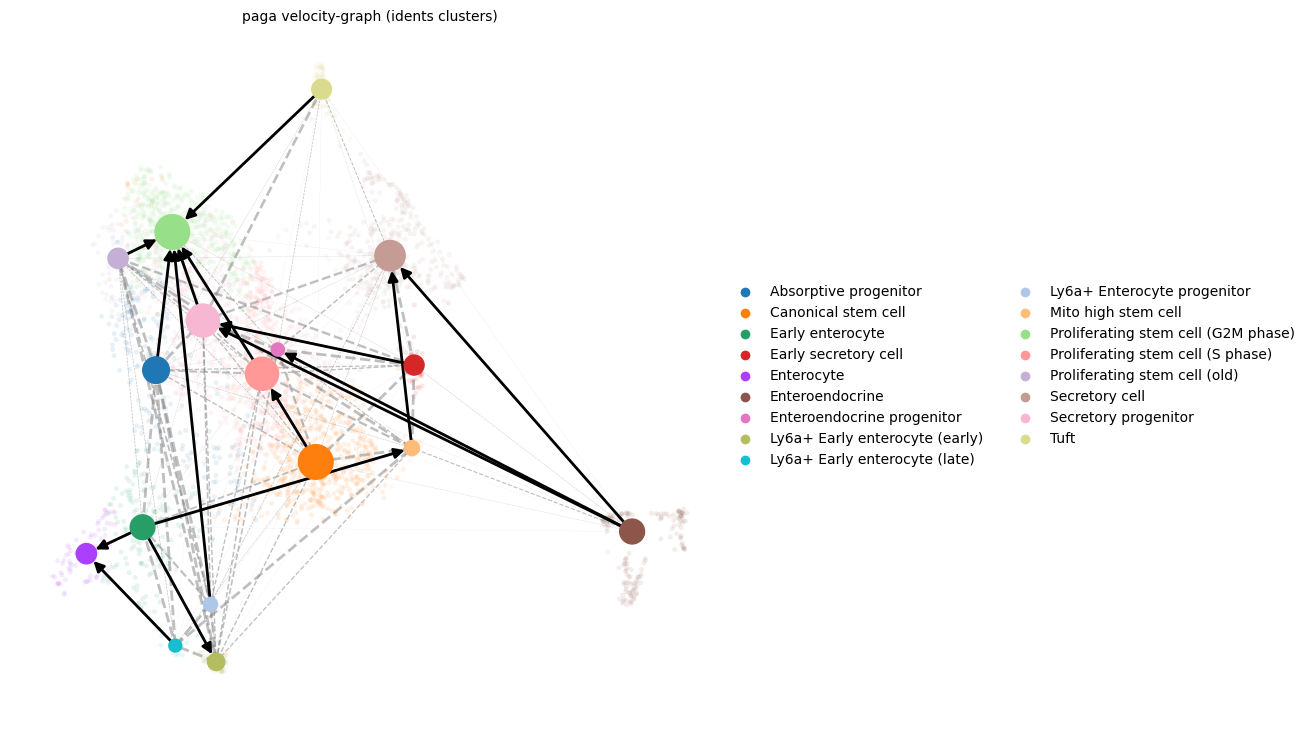

In [19]:
scv.pl.paga(dynamic_SAG, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5, figsize=(9,9))

In [20]:
clusters = dynamic_SAG.obs['idents_clusters'].astype('category').cat.categories
mat = dynamic_SAG.uns['paga']['transitions_confidence'].toarray()
df = pd.DataFrame(mat, index=clusters, columns=clusters)
df_long = df.stack().reset_index()
df_long.columns = ['source', 'target', 'value']
df_long = df_long[df_long['value'] > 0]

df_long.to_csv("dynamic_SAG_circos_input.tsv", sep="\t", index=False)

# PGE2

In [21]:
# dynamic
file_path = '/Users/choi_lab_sk/Library/CloudStorage/OneDrive-Personal/Choi_Lab_SK/project1_intestinal_crypt_bulk_scRNA-seq/sc_ver7/Trajectory_analysis/scVelo/3_PGE2/20250320_dynamic_PGE2_merge_data.h5ad'
dynamic_PGE2 = sc.read(file_path)

print(dynamic_PGE2)

AnnData object with n_obs × n_vars = 1872 × 21416
    obs: 'cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nUMI', 'nGene', 'Sample_Tag', 'Sample_Name', 'cells', 'log10GenesPerUMI', 'mitoRatio', 'batch', 'S.Score', 'G2M.Score', 'Phase', 'CC.Difference', 'RNA_snn_res.0.05', 'RNA_snn_res.0.1', 'RNA_snn_res.0.15', 'RNA_snn_res.0.2', 'RNA_snn_res.0.25', 'RNA_snn_res.0.3', 'RNA_snn_res.0.35', 'RNA_snn_res.0.4', 'seurat_clusters', 'mitoFr', 'RNA_snn_res.0.8', 'pANN_0.25_0.02_38', 'doublet_check', 'scDblFinder.class', 'scDblFinder.score', 'pANN_0.25_0.05_28', 'pANN_0.25_0.01_9', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.01', 'RNA_snn_res.0.02', 'RNA_snn_res.0.03', 'RNA_snn_res.0.04', 'RNA_snn_res.0.06', 'RNA_snn_res.0.07', 'RNA_snn_res.0.08', 'RNA_snn_res.0.09', 'RNA_snn_res.0.11', 'RNA_snn_res.0.12', 'RNA_snn_res.0.13', 'RNA_snn_res.0.14', 'RNA_snn_res.0.16', 'RNA_snn_res.0.17', 'RNA_snn_res.0.18', 'RNA_snn_res.0.19', 'RNA_snn_res.0.21', 'RNA_snn_res.0.22

In [23]:
dynamic_PGE2.uns['paga']

{'connectivities': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 234 stored elements in Compressed Sparse Row format>,
 'connectivities_tree': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 16 stored elements in Compressed Sparse Row format>,
 'groups': 'idents_clusters',
 'pos': array([[-3.12433788,  1.15773479],
        [ 1.96867612, -2.14710026],
        [-3.70367667, -5.169396  ],
        [ 4.69988158, -0.03189357],
        [-5.81525585, -4.73031547],
        [11.34150603, -3.88501717],
        [-1.46868077,  1.71426431],
        [-1.52672264, -7.31928833],
        [-2.88760206, -6.9596835 ],
        [-1.62060687, -5.80367263],
        [ 4.65555814, -1.84717132],
        [-2.74346218,  3.69279615],
        [-0.11839087,  0.12191645],
        [-4.5333024 ,  3.04276411],
        [ 4.05520895,  3.43962256],
        [-1.79581192,  1.49076812],
        [ 1.86233702,  6.99574987]]),
 'threshold': 0.01060248350467253,
 'transitions_confidence': <17x17 sparse

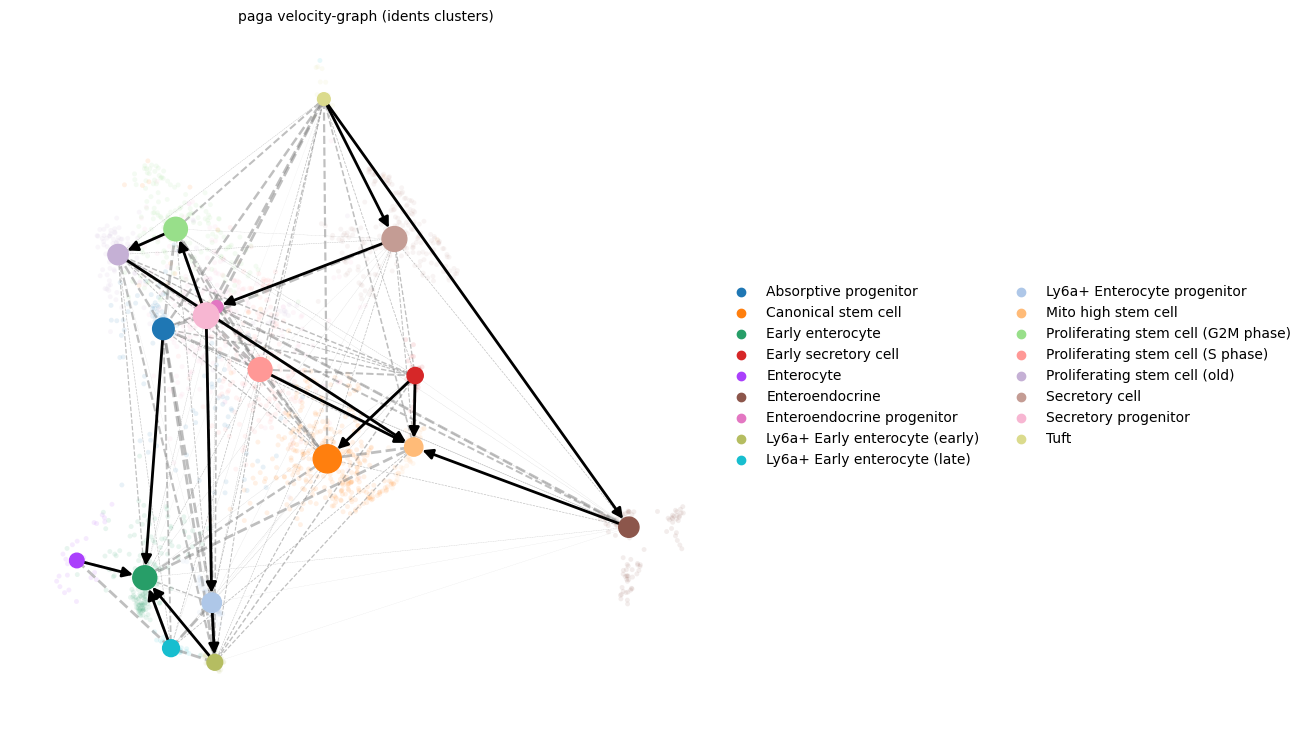

In [24]:
scv.pl.paga(dynamic_PGE2, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5, figsize=(9,9))

In [29]:
dynamic_PGE2.uns['paga']

{'connectivities': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 234 stored elements in Compressed Sparse Row format>,
 'connectivities_tree': <17x17 sparse matrix of type '<class 'numpy.float64'>'
 	with 16 stored elements in Compressed Sparse Row format>,
 'groups': 'idents_clusters',
 'pos': array([[-3.12433788,  1.15773479],
        [ 1.96867612, -2.14710026],
        [-3.70367667, -5.169396  ],
        [ 4.69988158, -0.03189357],
        [-5.81525585, -4.73031547],
        [11.34150603, -3.88501717],
        [-1.46868077,  1.71426431],
        [-1.52672264, -7.31928833],
        [-2.88760206, -6.9596835 ],
        [-1.62060687, -5.80367263],
        [ 4.65555814, -1.84717132],
        [-2.74346218,  3.69279615],
        [-0.11839087,  0.12191645],
        [-4.5333024 ,  3.04276411],
        [ 4.05520895,  3.43962256],
        [-1.79581192,  1.49076812],
        [ 1.86233702,  6.99574987]]),
 'threshold': 0.01060248350467253,
 'transitions_confidence': <17x17 sparse

In [25]:
clusters = dynamic_PGE2.obs['idents_clusters'].astype('category').cat.categories
mat = dynamic_PGE2.uns['paga']['transitions_confidence'].toarray()
df = pd.DataFrame(mat, index=clusters, columns=clusters)
df_long = df.stack().reset_index()
df_long.columns = ['source', 'target', 'value']
df_long = df_long[df_long['value'] > 0]  # 값 있는 것만 필터링

df_long.to_csv("dynamic_PGE2_circos_input.tsv", sep="\t", index=False)